In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

directory = './for_keep/bloodmnist_28'

all_dfs = []
for root, dirs, files in os.walk(directory):
    for file in files:
        if file == 'test_metrics.csv':
            # add a column for the run name and parent directory and make index continuous
            df = pd.read_csv(os.path.join(root, file))
            df['parent'] = os.path.basename(os.path.dirname(root))
            df['run'] = os.path.basename(root)
            df.index = range(len(df))            

            all_dfs.append(df)

df = pd.concat(all_dfs)
df = df[df.checkpoint != 'model-final']

wrn_lc_df = df[df['parent'] == 'wrn_lc']
wrn_random_df = df[df['parent'] == 'wrn_random']
wrn_sm_df = df[df['parent'] == 'wrn_sm']
wrn_entropy_df = df[df['parent'] == 'wrn_entropy']

def get_stats(df):
    metrics = ['test_cls_loss', 'test_cls_acc', 'test_cls_ece']
    stats_df = df.groupby(['parent', 'checkpoint'])[metrics].agg(['mean', 'std'])

    # Flatten the multi-level column names
    stats_df.columns = [f"{col[0]}_{col[1]}" for col in stats_df.columns]

    # Reset index to make parent and checkpoint regular columns
    stats_df = stats_df.reset_index()

    # Sort by parent and checkpoint number
    stats_df['checkpoint_num'] = stats_df['checkpoint'].str.extract(r'(\d+)').astype(int)
    stats_df = stats_df.sort_values(['parent', 'checkpoint_num'])
    stats_df = stats_df.drop('checkpoint_num', axis=1)
    
    return stats_df

wrn_lc_stats_df = get_stats(wrn_lc_df)
wrn_random_stats_df = get_stats(wrn_random_df)
wrn_sm_stats_df = get_stats(wrn_sm_df)
wrn_entropy_stats_df = get_stats( wrn_entropy_df)

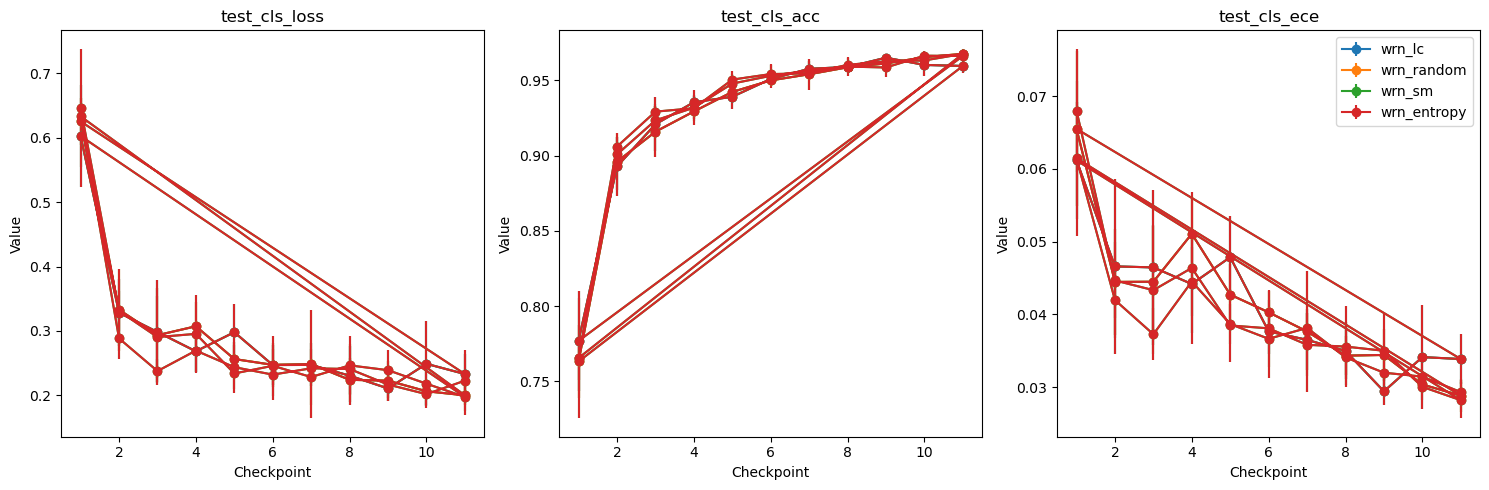

In [6]:
def plot_combined_stats(stats_dfs, labels, title):
    metrics = ['test_cls_loss', 'test_cls_acc', 'test_cls_ece']
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    for stats_df, label in zip(stats_dfs, labels):
        stats_df = stats_df.set_index('checkpoint')
        stats_df = stats_df.reset_index()  # Ensure 'parent' is not set as index

        # in checkpoint, retain only the number
        stats_df['checkpoint'] = stats_df['checkpoint'].str.extract(r'(\d+)').astype(int)
        for i, metric in enumerate(metrics):
            mean_col = f"{metric}_mean"
            std_col = f"{metric}_std"
            ax[i].errorbar(stats_df['checkpoint'], stats_df[mean_col], yerr=stats_df[std_col], label=label, fmt='-o')
            ax[i].set_title(metric)
            ax[i].set_xlabel('Checkpoint')
            ax[i].set_ylabel('Value')

    plt.tight_layout()
    plt.legend()
    plt.show()

plot_combined_stats([wrn_lc_stats_df, wrn_random_stats_df, wrn_sm_stats_df, wrn_entropy_stats_df], ['wrn_lc', 'wrn_random', 'wrn_sm', 'wrn_entropy'], 'BloodMNIST 28x28')